# Machine Learning Modeling

This notebook develops and evaluates machine learning models for materials property prediction.

## Steps
1. Load processed features
2. Train-test split
3. Model development (multiple algorithms)
4. Hyperparameter tuning
5. Model evaluation and comparison
6. Feature importance analysis

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, 
                             roc_curve, precision_recall_curve, f1_score, accuracy_score)
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

DATA_DIR = Path('../data')

# Load dataset
df_features = pd.read_csv(DATA_DIR / 'tm_oxygen_binary_compounds_magpie_features.csv')

print("Dataset loaded!")
print(f"Shape: {df_features.shape}")

# Prepare features
metadata_cols = ['material_id', 'formula', 'transition_metal']
property_cols = ['energy_above_hull', 'volume', 'density', 'band_gap', 'is_stable', 'is_metal']

feature_cols = [col for col in df_features.columns 
                if col not in metadata_cols + property_cols]

X = df_features[feature_cols].copy()

print(f"Features: {X.shape[1]}")
print(f"Samples: {len(X)}")

Dataset loaded!
Shape: (288, 141)
Features: 132
Samples: 288


## Investigating Stability

=== CLASSIFICATION TARGET: Stability ===

Stable (energy = 0): 21
Unstable (energy > 0): 267
Class ratio: 7.3% stable

Class weights (for imbalance):
  Unstable: 0.539
  Stable: 6.857


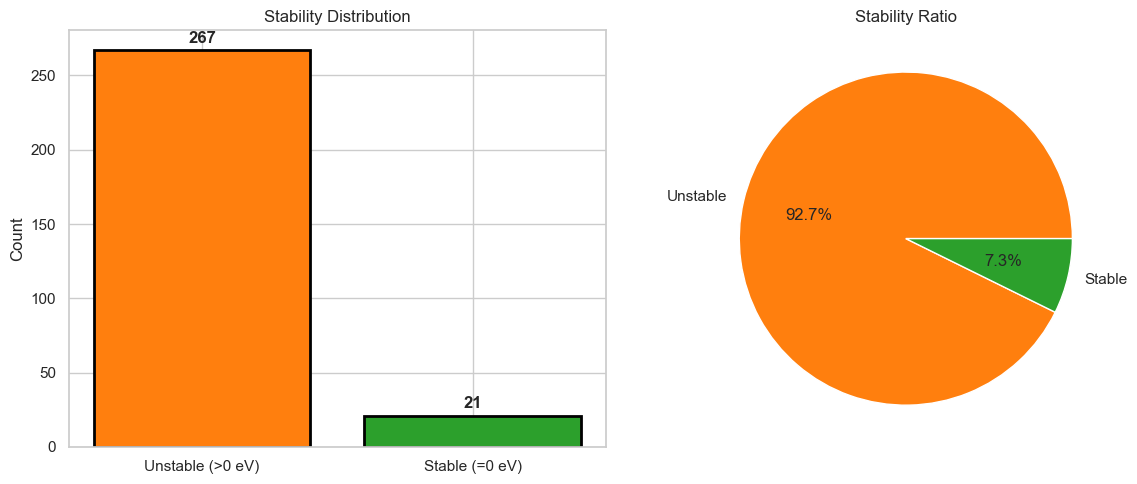

In [37]:
# Create binary stability target: 1 = stable (on convex hull), 0 = unstable
# Using energy_above_hull: 0 eV = stable, > 0 eV = unstable
y_stable = (df_features['energy_above_hull'] == 0).astype(int)

print("=== CLASSIFICATION TARGET: Stability ===\n")
print(f"Stable (energy = 0): {(y_stable == 1).sum()}")
print(f"Unstable (energy > 0): {(y_stable == 0).sum()}")
print(f"Class ratio: {(y_stable == 1).sum() / len(y_stable) * 100:.1f}% stable")

# Check for class imbalance
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced', classes=np.unique(y_stable), y=y_stable)
print(f"\nClass weights (for imbalance):")
print(f"  Unstable: {class_weights[0]:.3f}")
print(f"  Stable: {class_weights[1]:.3f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot
stability_counts = y_stable.value_counts()
axes[0].bar(['Unstable (>0 eV)', 'Stable (=0 eV)'], [stability_counts[0], stability_counts[1]], 
            color=['#ff7f0e', '#2ca02c'], edgecolor='black', linewidth=2)
axes[0].set_ylabel('Count')
axes[0].set_title('Stability Distribution')
for i, v in enumerate([stability_counts[0], stability_counts[1]]):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie([stability_counts[0], stability_counts[1]], 
            labels=['Unstable', 'Stable'], 
            autopct='%1.1f%%',
            colors=['#ff7f0e', '#2ca02c'])
axes[1].set_title('Stability Ratio')

plt.tight_layout()
plt.show()

In [38]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Features standardized!")
print(f"Mean: {X_scaled.mean().mean():.6f}")
print(f"Std: {X_scaled.std().mean():.6f}")

Features standardized!
Mean: -0.000000
Std: 0.743717


In [39]:
print("=== Top 15 Features Correlated with Stability ===")
correlations = []
for col in X_scaled.columns:
    # Point-biserial correlation for binary classification
    corr = X_scaled[col].corr(y_stable)
    correlations.append((col, corr))

correlations.sort(key=lambda x: abs(x[1]), reverse=True)

for feat, corr in correlations[:15]:
    print(f"  {feat}: {corr:.6f}")

=== Top 15 Features Correlated with Stability ===
  MagpieData minimum Number: nan
  MagpieData avg_dev Number: 0.168948
  MagpieData maximum MendeleevNumber: nan
  MagpieData minimum AtomicWeight: nan
  MagpieData minimum MeltingT: nan
  MagpieData maximum Column: nan
  MagpieData range Column: -0.172555
  MagpieData minimum Column: 0.172555
  MagpieData mean Number: 0.168908
  MagpieData avg_dev AtomicWeight: 0.160703
  MagpieData mean AtomicWeight: 0.160632
  MagpieData minimum MendeleevNumber: 0.158827
  MagpieData range MendeleevNumber: -0.158827
  MagpieData avg_dev Column: -0.155124
  MagpieData range Number: 0.142936


In [40]:
# Set up 5-Fold Cross Validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Define scoring metrics for classification
scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'precision': 'precision',
    'recall': 'recall'
}

# Initialize models with class weights to handle imbalance
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

models = {
    'Logistic Regression': LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight='balanced'
    ),
    'Random Forest (Shallow)': RandomForestClassifier(
        n_estimators=100,
        max_depth=8,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ),
    'Random Forest (Medium)': RandomForestClassifier(
        n_estimators=100,
        max_depth=12,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42
    )
}

# Run cross-validation for each model
results = {}

for model_name, model in models.items():
    print(f"Training {model_name}...")
    cv_results = cross_validate(model, X_scaled, y_stable, cv=kfold, 
                                scoring=scoring, return_train_score=True)
    results[model_name] = cv_results

print("\n✓ All models trained!")

Training Logistic Regression...
Training Random Forest (Shallow)...
Training Random Forest (Medium)...
Training Gradient Boosting...

✓ All models trained!


In [41]:
print("=== 5-FOLD CROSS VALIDATION RESULTS ===\n")

for model_name, cv_results in results.items():
    train_acc = cv_results['train_accuracy']
    test_acc = cv_results['test_accuracy']
    train_f1 = cv_results['train_f1']
    test_f1 = cv_results['test_f1']
    train_auc = cv_results['train_roc_auc']
    test_auc = cv_results['test_roc_auc']
    test_precision = cv_results['test_precision']
    test_recall = cv_results['test_recall']
    
    print(f"\n{model_name}:")
    print(f"  Accuracy - Train: {train_acc.mean():.4f} ± {train_acc.std():.4f}")
    print(f"             Test: {test_acc.mean():.4f} ± {test_acc.std():.4f}")
    print(f"  F1 Score - Train: {train_f1.mean():.4f} ± {train_f1.std():.4f}")
    print(f"             Test: {test_f1.mean():.4f} ± {test_f1.std():.4f}")
    print(f"  ROC AUC  - Train: {train_auc.mean():.4f} ± {train_auc.std():.4f}")
    print(f"             Test: {test_auc.mean():.4f} ± {test_auc.std():.4f}")
    print(f"  Precision (Test): {test_precision.mean():.4f} ± {test_precision.std():.4f}")
    print(f"  Recall (Test): {test_recall.mean():.4f} ± {test_recall.std():.4f}")

=== 5-FOLD CROSS VALIDATION RESULTS ===


Logistic Regression:
  Accuracy - Train: 0.8420 ± 0.0169
             Test: 0.7883 ± 0.0466
  F1 Score - Train: 0.4286 ± 0.0233
             Test: 0.1885 ± 0.0980
  ROC AUC  - Train: 0.9171 ± 0.0166
             Test: 0.5494 ± 0.1163
  Precision (Test): 0.1387 ± 0.0722
  Recall (Test): 0.3467 ± 0.2075

Random Forest (Shallow):
  Accuracy - Train: 0.9575 ± 0.0127
             Test: 0.8959 ± 0.0288
  F1 Score - Train: 0.7609 ± 0.0648
             Test: 0.2794 ± 0.1691
  ROC AUC  - Train: 0.9832 ± 0.0053
             Test: 0.6834 ± 0.1407
  Precision (Test): 0.2952 ± 0.1978
  Recall (Test): 0.2967 ± 0.1694

Random Forest (Medium):
  Accuracy - Train: 0.9931 ± 0.0059
             Test: 0.9167 ± 0.0066
  F1 Score - Train: 0.9558 ± 0.0374
             Test: 0.1143 ± 0.1400
  ROC AUC  - Train: 0.9979 ± 0.0016
             Test: 0.6872 ± 0.1413
  Precision (Test): 0.1667 ± 0.2108
  Recall (Test): 0.0900 ± 0.1114

Gradient Boosting:
  Accuracy - Train: 

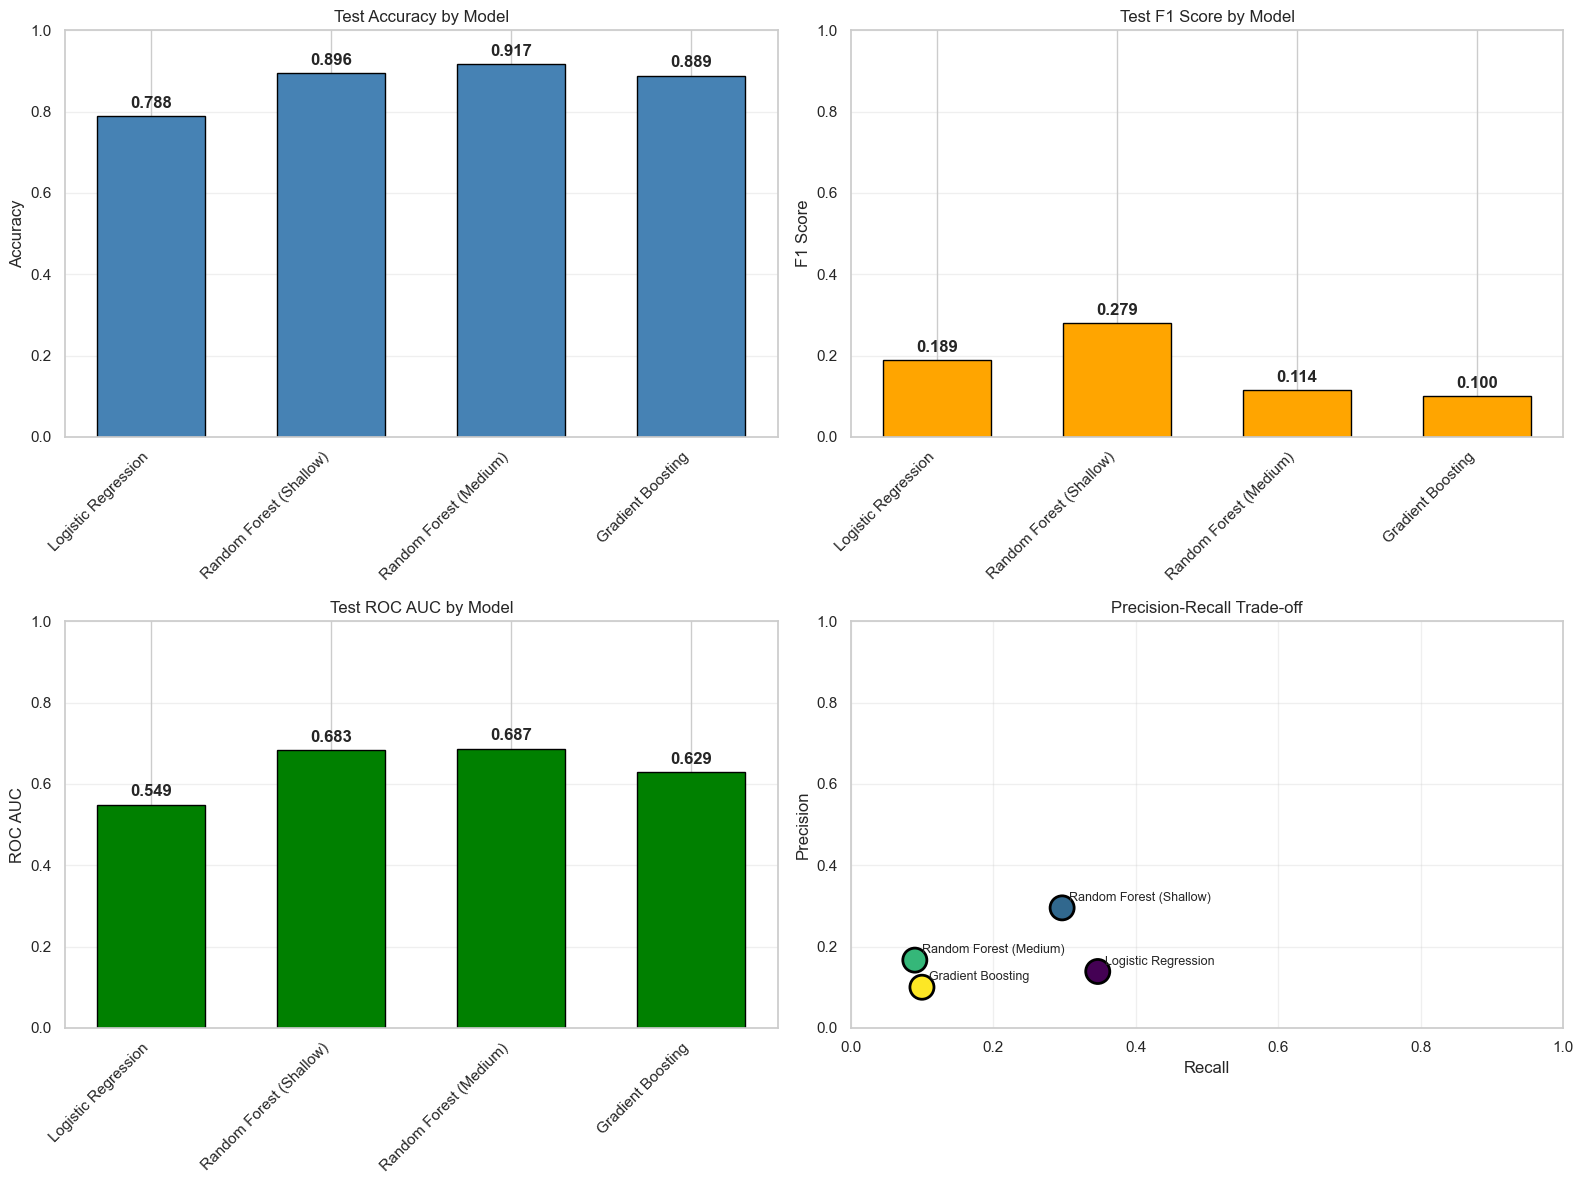

In [42]:
# Compare models
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

model_names = list(results.keys())
test_acc_scores = [results[m]['test_accuracy'].mean() for m in model_names]
test_f1_scores = [results[m]['test_f1'].mean() for m in model_names]
test_auc_scores = [results[m]['test_roc_auc'].mean() for m in model_names]
test_precision_scores = [results[m]['test_precision'].mean() for m in model_names]
test_recall_scores = [results[m]['test_recall'].mean() for m in model_names]

x = np.arange(len(model_names))
width = 0.6

# Accuracy
axes[0, 0].bar(x, test_acc_scores, width, color='steelblue', edgecolor='black')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Test Accuracy by Model')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(model_names, rotation=45, ha='right')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(test_acc_scores):
    axes[0, 0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# F1 Score
axes[0, 1].bar(x, test_f1_scores, width, color='orange', edgecolor='black')
axes[0, 1].set_ylabel('F1 Score')
axes[0, 1].set_title('Test F1 Score by Model')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(model_names, rotation=45, ha='right')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(test_f1_scores):
    axes[0, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# ROC AUC
axes[1, 0].bar(x, test_auc_scores, width, color='green', edgecolor='black')
axes[1, 0].set_ylabel('ROC AUC')
axes[1, 0].set_title('Test ROC AUC by Model')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(model_names, rotation=45, ha='right')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(test_auc_scores):
    axes[1, 0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# Precision vs Recall
axes[1, 1].scatter(test_recall_scores, test_precision_scores, s=300, 
                   c=range(len(model_names)), cmap='viridis', edgecolors='black', linewidth=2)
for i, name in enumerate(model_names):
    axes[1, 1].annotate(name, (test_recall_scores[i], test_precision_scores[i]), 
                       xytext=(5, 5), textcoords='offset points', fontsize=9)
axes[1, 1].set_xlabel('Recall')
axes[1, 1].set_ylabel('Precision')
axes[1, 1].set_title('Precision-Recall Trade-off')
axes[1, 1].set_xlim([0, 1])
axes[1, 1].set_ylim([0, 1])
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Best model (by F1 score): Random Forest (Shallow)
Test F1: 0.2794

Top 20 Most Important Features:
                                  feature  importance
10     MagpieData avg_dev MendeleevNumber    0.047011
3                  MagpieData mean Number    0.040900
15           MagpieData mean AtomicWeight    0.037566
64           MagpieData avg_dev NdValence    0.034146
28              MagpieData avg_dev Column    0.030012
34                 MagpieData avg_dev Row    0.028656
1               MagpieData maximum Number    0.025880
105             MagpieData mean NUnfilled    0.025718
4               MagpieData avg_dev Number    0.024816
52           MagpieData avg_dev NsValence    0.023730
45      MagpieData mean Electronegativity    0.023526
46   MagpieData avg_dev Electronegativity    0.022011
109        MagpieData maximum GSvolume_pa    0.021753
112        MagpieData avg_dev GSvolume_pa    0.020951
33                    MagpieData mean Row    0.020147
16        MagpieData avg_dev AtomicWe

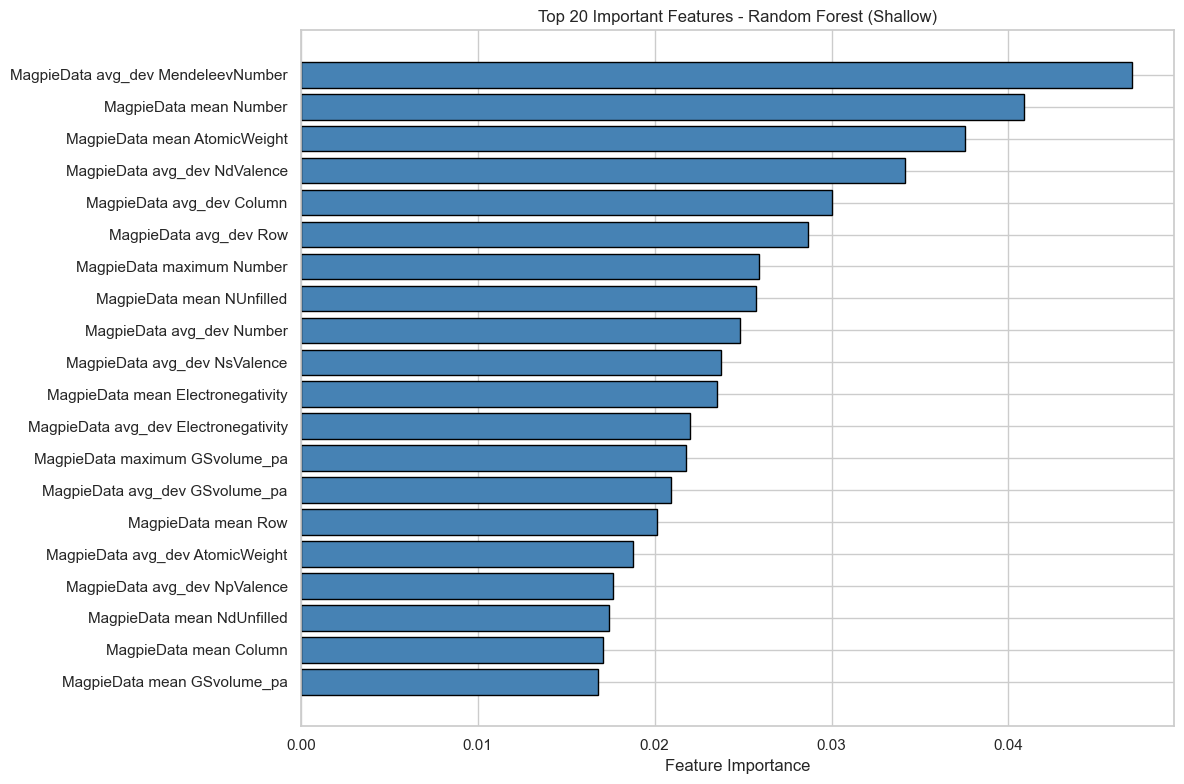

In [43]:
# Find best model by F1 score
best_model_name = max(results, key=lambda m: results[m]['test_f1'].mean())
print(f"Best model (by F1 score): {best_model_name}")
print(f"Test F1: {results[best_model_name]['test_f1'].mean():.4f}")

# Train final model to get feature importances
if 'Forest' in best_model_name or 'Gradient' in best_model_name:
    best_model = models[best_model_name]
    best_model.fit(X_scaled, y_stable)
    
    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\nTop 20 Most Important Features:")
    print(feature_importance.head(20))
    
    # Plot
    plt.figure(figsize=(12, 8))
    top_features = feature_importance.head(20)
    plt.barh(range(len(top_features)), top_features['importance'], color='steelblue', edgecolor='black')
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Feature Importance')
    plt.title(f'Top 20 Important Features - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
elif 'Logistic' in best_model_name:
    best_model = models[best_model_name]
    best_model.fit(X_scaled, y_stable)
    
    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'coefficient': best_model.coef_[0],
        'abs_coefficient': np.abs(best_model.coef_[0])
    }).sort_values('abs_coefficient', ascending=False)
    
    print("\nTop 20 Most Important Features (by coefficient):")
    print(feature_importance[['feature', 'coefficient']].head(20))
    
    # Plot
    plt.figure(figsize=(12, 8))
    top_features = feature_importance.head(20)
    colors = ['green' if x > 0 else 'red' for x in top_features['coefficient']]
    plt.barh(range(len(top_features)), top_features['coefficient'], color=colors, edgecolor='black')
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Coefficient (Feature Importance)')
    plt.title(f'Top 20 Important Features - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

=== CONFUSION MATRIX ===
True Negatives (Correctly predicted unstable): 259
False Positives (Predicted stable, actually unstable): 8
False Negatives (Predicted unstable, actually stable): 3
True Positives (Correctly predicted stable): 18


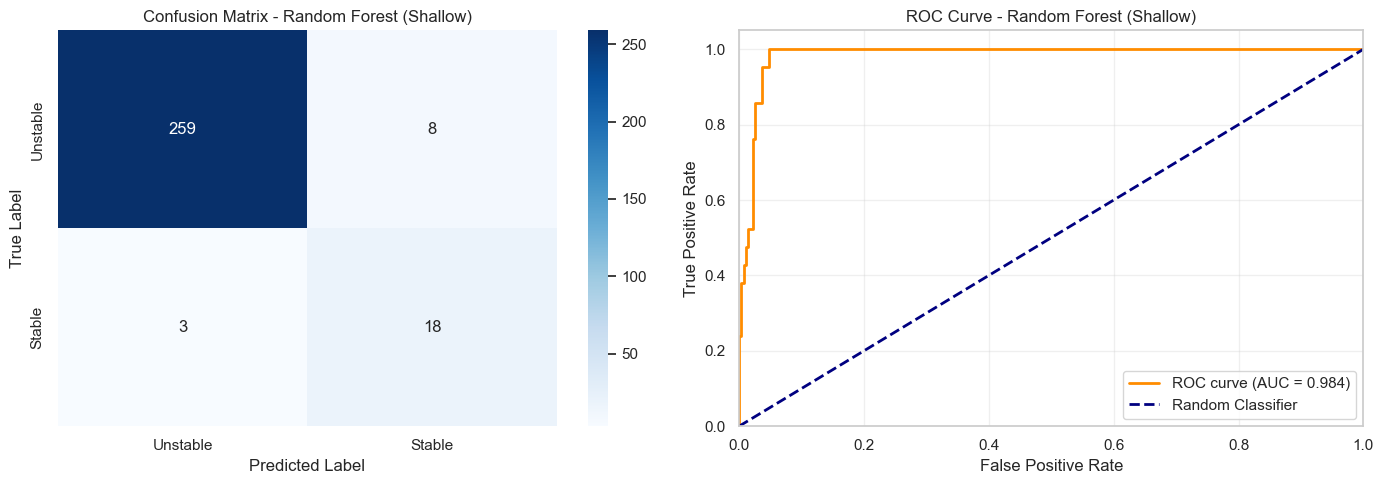


=== DETAILED CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Unstable       0.99      0.97      0.98       267
      Stable       0.69      0.86      0.77        21

    accuracy                           0.96       288
   macro avg       0.84      0.91      0.87       288
weighted avg       0.97      0.96      0.96       288



In [44]:
# Train best model and get predictions on full dataset
best_model = models[best_model_name]
best_model.fit(X_scaled, y_stable)
y_pred = best_model.predict(X_scaled)
y_pred_proba = best_model.predict_proba(X_scaled)[:, 1]

# Confusion matrix
cm = confusion_matrix(y_stable, y_pred)
print("=== CONFUSION MATRIX ===")
print(f"True Negatives (Correctly predicted unstable): {cm[0, 0]}")
print(f"False Positives (Predicted stable, actually unstable): {cm[0, 1]}")
print(f"False Negatives (Predicted unstable, actually stable): {cm[1, 0]}")
print(f"True Positives (Correctly predicted stable): {cm[1, 1]}")

# Visualize confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Unstable', 'Stable'],
            yticklabels=['Unstable', 'Stable'])
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].set_title(f'Confusion Matrix - {best_model_name}')

# ROC Curve
fpr, tpr, _ = roc_curve(y_stable, y_pred_proba)
roc_auc = roc_auc_score(y_stable, y_pred_proba)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'ROC Curve - {best_model_name}')
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n=== DETAILED CLASSIFICATION REPORT ===")
print(classification_report(y_stable, y_pred, target_names=['Unstable', 'Stable']))

## TODO: Add Modeling Code
- Train-test split
- Feature scaling
- Model training (Random Forest, XGBoost, etc.)
- Cross-validation
- Hyperparameter tuning
- Model evaluation metrics
- Feature importance analysis with SHAP